# Heart Disease Classification — Modelling

**Problem.** Given a patient's anonymised clinical measurements, can we predict whether or not they have heart disease (binary classification)?

**Data.** The UCI Cleveland heart disease dataset (303 rows, 13 features). See [`../docs/data_dictionary.md`](../docs/data_dictionary.md) for a description of every column.

**Evaluation.** As a proof of concept we set an (aspirational) target of **95% accuracy**. Because the dataset is small we lean on cross-validation rather than a separate validation set.

**Workflow:** baseline models → hyperparameter tuning → evaluation beyond accuracy → feature importance. Exploratory data analysis lives in [`01-heart-disease-eda.ipynb`](01-heart-disease-eda.ipynb).

In [1]:
# Regular EDA and plotting libraries
import numpy as np # np is short for numpy

import pandas as pd # pandas is so commonly used, it's shortened to pd

import matplotlib
import matplotlib.pyplot as plt

import seaborn as sns # seaborn gets shortened to sns

## Models
import sklearn 
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

## Model evaluators
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
# from sklearn.metrics import plot_roc_curve # note: this was changed in Scikit-Learn 1.2+ to be "RocCurveDisplay" (see below)
from sklearn.metrics import RocCurveDisplay # new in Scikit-Learn 1.2+

# Print last updated
import datetime
print(f"Notebook last updated: {datetime.datetime.now()}\n")

# Print versions of libraries we're using (as long as yours are equal or greater than these, your code should work)
print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"Scikit-Learn version: {sklearn.__version__}")

Notebook last updated: 2026-07-28 18:56:52.720684

NumPy version: 1.26.4
pandas version: 3.0.2
matplotlib version: 3.8.2
Scikit-Learn version: 1.9.0


In [2]:
# Load Data
df = pd.read_csv("../data/raw/heart-disease.csv")

# Baseline Models

### Creating a training and test split

In [3]:
# Features
X = df.drop(labels="target", axis=1)

# Target variable
y = df.target.to_numpy()

X.head()
y, type(y)

(array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [4]:
# Random seed for reproducability
np.random.seed(42)

# Split into train & test set
X_train, X_test, y_train, y_test = train_test_split(X, #independant
                                                    y, #dependant
                                                    test_size=0.2) # 20% for test set

X_train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,42,1,1,120,295,0,1,162,0,0.0,2,0,2
202,58,1,0,150,270,0,0,111,1,0.8,2,0,3
196,46,1,2,150,231,0,1,147,0,3.6,1,0,2
75,55,0,1,135,250,0,0,161,0,1.4,1,0,2
176,60,1,0,117,230,1,1,160,1,1.4,2,2,3


### Testing out models

Exploring the following models:
1. Logistic Regression
2. K-Nearest Neighbors
3. Random Forest


In [5]:
import sys
sys.path.append("..")
from src.models.evaluate import fit_and_score

# Put models in dictionary
models = {"KNN" : KNeighborsClassifier(),
          "Logistic Regression": LogisticRegression(max_iter=100),
          "Random Forest" : RandomForestClassifier()}

model_scores = fit_and_score(models=models,
                             X_train=X_train,
                             X_test=X_test,
                             y_train=y_train,
                             y_test=y_test)

model_scores


C:\Users\adamw\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'KNN': 0.6885245901639344,
 'Logistic Regression': 0.8852459016393442,
 'Random Forest': 0.8360655737704918}

### Comparing the results of several Models

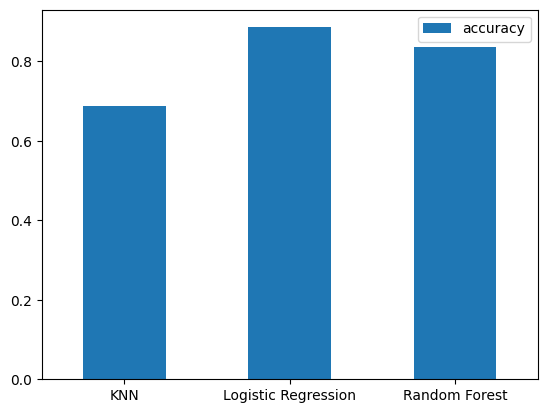

In [6]:
model_compare = pd.DataFrame(model_scores, index=["accuracy"])
model_compare.T.plot.bar(rot=0);

# Hyperparameter tuning and cross-validation
Given the limited amount of data, we'll use cross-validation as oppose to creating and using a validation set.

### Tuning KNN by hand


Maximum KNN score on the test data: 75.41%


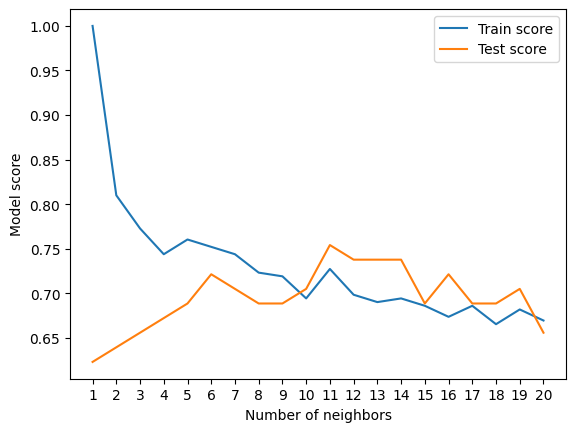

In [7]:
# List of train scores
train_scores = []

# List of test scores
test_scores = []

# List of values for n_neighbors
neighbors = range(1, 21)

# Algorithm setup
knn = KNeighborsClassifier()

# Iterate through different neighbor values
for i in neighbors:
    knn.set_params(n_neighbors = i) 

    # Fit and notes scores
    knn.fit(X_train, y_train)
    train_scores.append(knn.score(X_train, y_train))
    test_scores.append(knn.score(X_test, y_test))

train_scores

# Visualise the data
plt.plot(neighbors, train_scores, label="Train score")
plt.plot(neighbors, test_scores, label="Test score")
plt.xticks(np.arange(1,21,1))
plt.xlabel("Number of neighbors")
plt.ylabel("Model score")
plt.legend()

print(f"Maximum KNN score on the test data: {max(test_scores)*100:.2f}%")

Based on the graph, it seems that `n_neighbors = 11` yields the best results.

However, even after tuning, `KNN`'s performance did not get near the scores produced by`LogisticRegression` or `RandomForestClassifier` so we will discard `KNN` and focus on the other two

### Tuning models with `RanomizedSearchCV`
##### Creating a hyperparameter grid


In [8]:
# Different LogisticRegression hyperparameters
log_reg_grid = {"C" : np.logspace(-4, 4, 20),
                "solver" : ["liblinear"]}

# Different RandomForestClassifier hyperparameters
rf_grid = {"n_estimators" : np.arange(10, 1000, 50),
           "max_depth" : [None, 3, 5, 10],
           "min_samples_split" : np.arange(2, 20, 2),
           "min_samples_leaf" : np.arange(1, 20, 2)}

#### Testing out different hyperparameters
##### LogisticRegression

In [9]:
%%time

np.random.seed(42)

# Setup random hyperparameter seach for Logistic Regression
rs_log_reg = RandomizedSearchCV(
                                estimator=LogisticRegression(),
                                param_distributions=log_reg_grid,
                                cv=5,
                                n_iter=20,
                                verbose=True)
# Fit the model
rs_log_reg.fit(X_train, y_train)

# Best parameters found
print(rs_log_reg.best_params_)

rs_log_reg.score(X_test, y_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


{'solver': 'liblinear', 'C': 0.23357214690901212}
CPU times: total: 469 ms
Wall time: 481 ms


0.8852459016393442

##### RandomForestClassifier

In [10]:
%%time

np.random.seed(42)

# setup hyperparameter search for RFC
rs_rf = RandomizedSearchCV(
                            estimator=RandomForestClassifier(),
                            param_distributions=rf_grid,
                            cv=5,
                            n_iter=20,
                            n_jobs=-1,
                            verbose=True)
rs_rf.fit(X_train, y_train)

# Best params
print(rs_rf.best_params_)

rs_rf.score(X_test, y_test)



Fitting 5 folds for each of 20 candidates, totalling 100 fits


{'n_estimators': 10, 'min_samples_split': 16, 'min_samples_leaf': 9, 'max_depth': None}
CPU times: total: 469 ms
Wall time: 15.3 s


0.8524590163934426

### Tuning `LogisticRegression` further with `GridSearchCV`
Since `LogisticRegression` pulled out in front, we'll attempt to tune it even further with `GridSearchCV`

In [11]:
%%time

# Different LR hyperparameters
log_reg_grid = {"C" : np.logspace(-4, 4, 20),
                "solver" : ["liblinear"]}

# Setup gird hyperparameter search
gs_log_reg = GridSearchCV(
                        estimator=LogisticRegression(),
                        param_grid=log_reg_grid,
                        cv=5,
                        n_jobs=-1,
                        verbose=True)
# Fit model
gs_log_reg.fit(X_train, y_train)

print(gs_log_reg.best_params_)

# Evaluate model
gs_log_reg.score(X_test, y_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'C': 0.23357214690901212, 'solver': 'liblinear'}
CPU times: total: 93.8 ms
Wall time: 186 ms


0.8852459016393442

# Evaluating our tuned Model

A single accuracy score hides *where* a model goes wrong. Below we evaluate the tuned `LogisticRegression` beyond accuracy — using a ROC curve, a confusion matrix, a classification report and cross-validated metrics — then inspect which features drive its decisions.

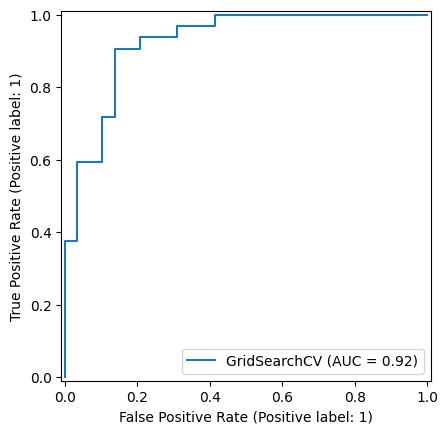

In [12]:
from sklearn.metrics import RocCurveDisplay

# Plot the ROC cruve on data
RocCurveDisplay.from_estimator(estimator=gs_log_reg,
                               X=X_test,
                               y=y_test)

### Creating a confusion matrix

[[25  4]
 [ 3 29]]


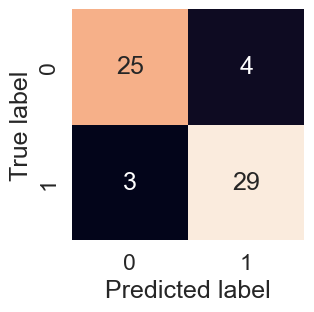

In [13]:
# Retrieve predicted values
y_preds = gs_log_reg.predict(X_test)

# Display the confusion matrix
print(confusion_matrix(y_test, y_preds))

# Visualise the matrix as a heatmap
sns.set(font_scale=1.5)

def plot_conf_mat(y_test, y_preds):
    """
    Plots a confusion matrix using Seaborn's heatmap().
    """
    fig, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True,
                     cbar=False)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

plot_conf_mat(y_test, y_preds)

### Making a Classification Report

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



Accuracy: 0.8480
Precision: 0.8216
Recall: 0.9273
F1: 0.8705
CPU times: total: 109 ms
Wall time: 98 ms


<Axes: title={'center': 'Cross-Validated Metrics'}>

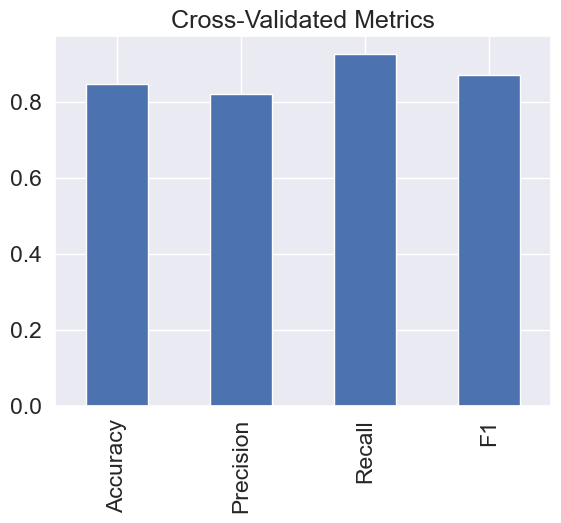

In [14]:
%%time
# Show classification report
print(classification_report(y_test, y_preds))

# Recreate the tuned model, then cross-validate it across several metrics
clf = LogisticRegression(C=0.23357214690901212,
                         solver="liblinear")

# Evaluate accuracy, precision, recall and F1 in a single 5-fold pass
cv_results = cross_validate(clf,
                            X,
                            y,
                            cv=5,
                            scoring=["accuracy", "precision", "recall", "f1"])

# Print the mean of each metric (skip the fit/score timing keys)
for metric, scores in cv_results.items():
    if metric.startswith("test_"):
        print(f"{metric.replace('test_', '').title()}: {np.mean(scores):.4f}")

# Visualise the cross-validated metrics
cv_metrics = pd.DataFrame({
    "Accuracy": np.mean(cv_results["test_accuracy"]),
    "Precision": np.mean(cv_results["test_precision"]),
    "Recall": np.mean(cv_results["test_recall"]),
    "F1": np.mean(cv_results["test_f1"])
}, index=[0])

cv_metrics.T.plot.bar(title="Cross-Validated Metrics", legend=False)

## Feature Importance
Feature importance differs across various models, as well as the methods used for finding which features were most important. The feature importance of one model won't necessarily reflect the feature importance of another. 

As we were using `LogisticRegression`, we will investigate one way we can calculate feature importance for it.

We will use the `coef_` attribute: the coefficient of the features in the decision function.

In [15]:
# Fit an instance of LogisticRegression
clf.fit(X_train, y_train)

# Check coef_
clf.coef_

array([[ 0.00369922, -0.9042409 ,  0.67472826, -0.0116134 , -0.00170364,
         0.04787688,  0.33490196,  0.02472938, -0.63120405, -0.57590944,
         0.47095136, -0.65165348, -0.69984207]])

As always, its hard to read numbers, therefore we will visualize:

<Axes: title={'center': 'Feature Importance'}>

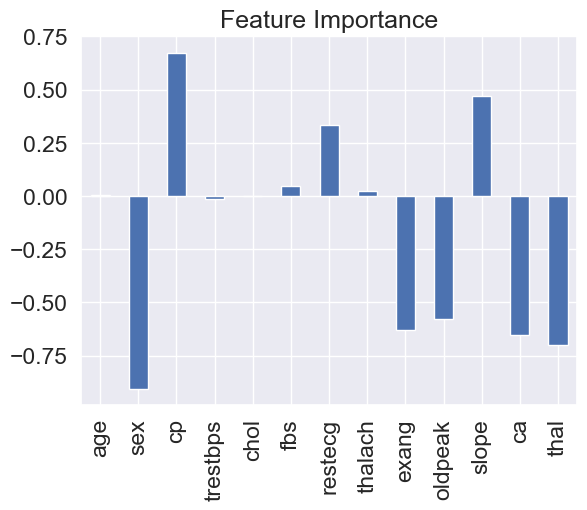

In [16]:
# Match features to columns
features_dict = dict(zip(X.columns, list(clf.coef_[0])))

# Visualize feature importance
features_df = pd.DataFrame(features_dict, index=[0])
features_df.T.plot.bar(title="Feature Importance", legend=False)

The larger the bar, the more the feature contributes to the model's decision.

If the value is negative, it means there's a negative correlation. And vice versa for positive value.

# Conclusion

**Did we hit the target?** Not quite. The tuned `LogisticRegression` reached **~0.89 accuracy on the hold-out test split** and **~0.85 accuracy under 5-fold cross-validation** — short of the 95% proof-of-concept goal, but in line with the accuracy ceiling widely reported for this small (303-row) dataset.

**Beyond accuracy.** Recall on the positive (has-disease) class matters most here — a false negative means missing a sick patient. Cross-validated recall is **~0.93**, so the model catches most true cases, with cross-validated precision ~0.82 and F1 ~0.87.

**What drives predictions.** From the `LogisticRegression` coefficients, chest pain type (`cp`) and the slope of the peak exercise ST segment (`slope`) push most strongly toward a positive prediction, while sex (`sex`), number of major vessels (`ca`) and exercise-induced angina (`exang`) push toward negative.

**Next steps.** The highest-leverage improvement would be *more and better data*, not more model types — the models tried already cluster tightly. Other avenues: a wider hyperparameter search, engineered features, or a stronger model family (e.g. gradient boosting). For this practice project the goal was the end-to-end workflow, and that is complete.